# # 03 — Prétraitement : nettoyage et exploration visuelle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 

df = pd.read_csv(r"C:\Users\PC\Documents\pfa-photovoltaique\pfa-photovoltaique\data\merged_5min_day.csv", index_col="time", parse_dates=True)
print(f"{len(df):,} lignes x {len(df.columns)} colonnes")
df.head()

53,016 lignes x 12 colonnes


,DTI,GTI,TA,TPV,Ia,Ig,Eg,Fg,Pg,Va,Vg,Fault
time,,,,,,,,,,,,
2021-10-28 12:35:00+00:00,160.909630,232.833333,27.386222,31.059185,1.145000,0.921667,7.992600,49.185333,222.516667,186.250000,227.166667,0.0
2021-10-28 12:40:00+00:00,199.746000,235.822000,27.511533,31.682300,1.483333,1.130000,8.003800,50.018167,275.916667,189.583333,232.050000,0.0
2021-10-28 12:45:00+00:00,176.863333,183.124667,26.819167,31.889133,1.170000,0.930000,8.013800,50.009833,226.450000,185.850000,231.666667,0.0
2021-10-28 12:50:00+00:00,129.183000,156.106000,26.769000,31.021833,0.883333,0.741667,8.020000,50.017667,181.866667,187.933333,231.883333,0.0
2021-10-28 12:55:00+00:00,105.944333,241.443667,27.501333,30.573133,1.070270,0.894595,8.025081,50.026486,218.864865,191.756757,232.864865,0.0


# 1. Boîtes à moustaches — repérer les outliers capteurs

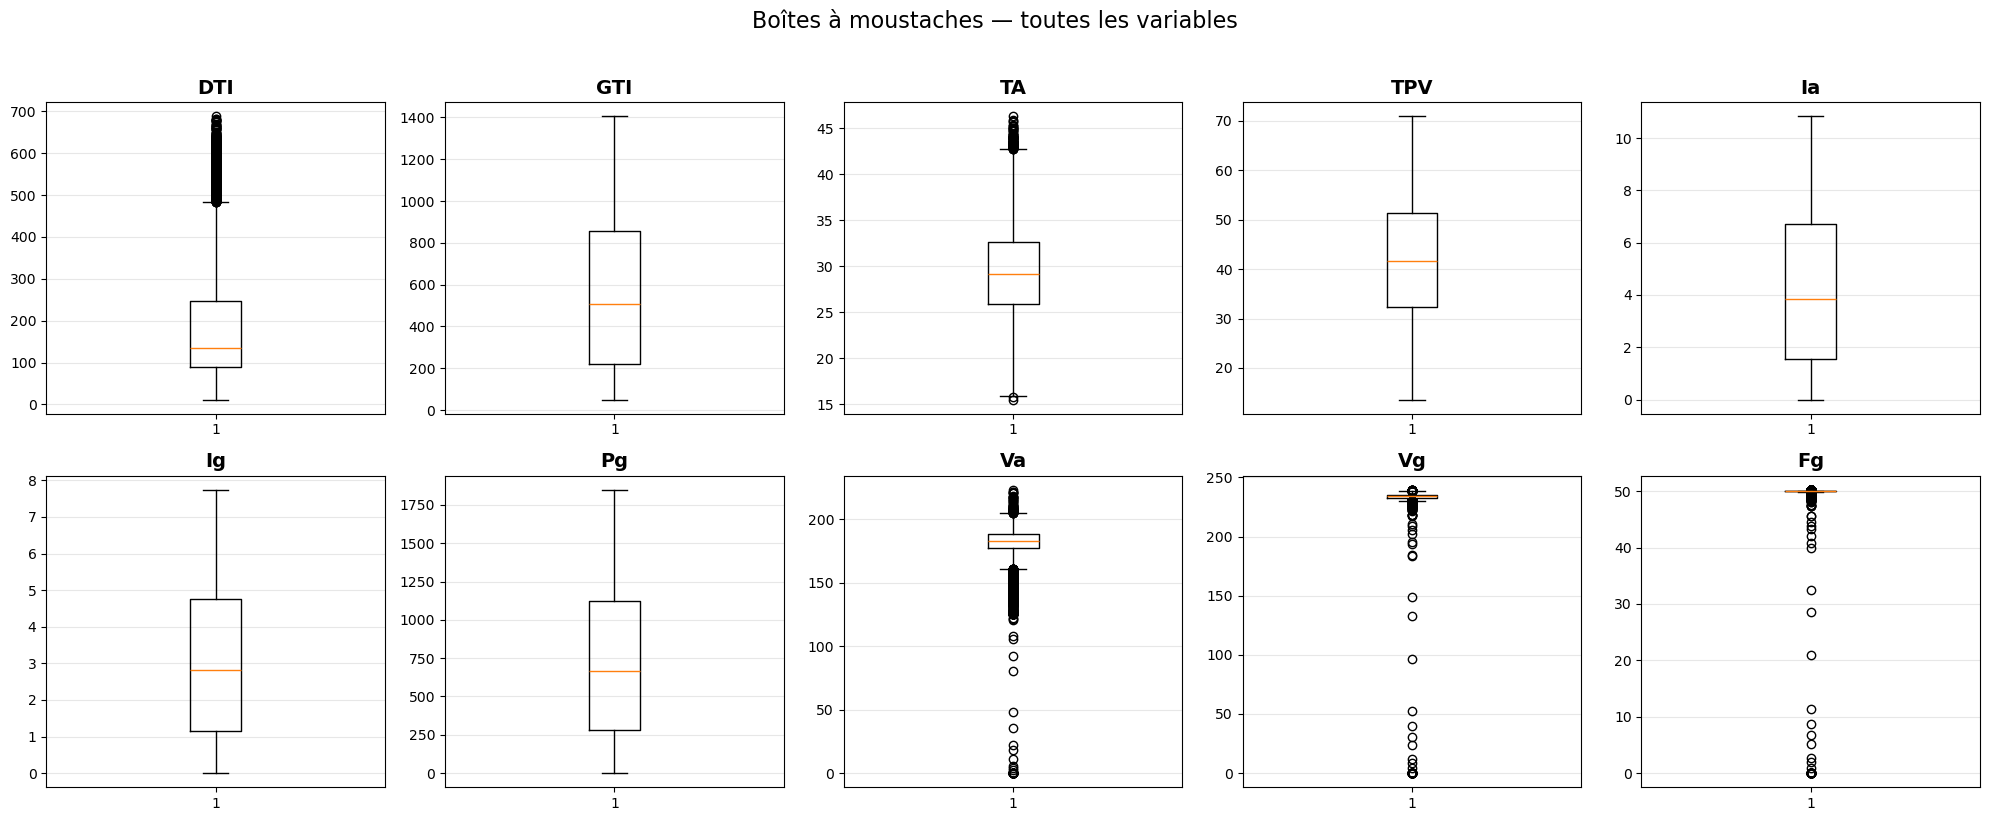

In [8]:
features = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg"]
 
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
 
for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=14, fontweight="bold")
    axes[i].grid(axis="y", alpha=0.3)
 
fig.suptitle("Boîtes à moustaches — toutes les variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

 

# 2. Valeurs suspectes — vérification physique

 - Va ou Vg à 0 ? → capteur déconnecté
 - Pg négatif ? → erreur
 - GTI > 1500 ? → valeur irréaliste
 - TPV < 0 ? → possible erreur nocturne résiduelle

In [9]:
print("=== Valeurs suspectes ===")
print(f"Va == 0     : {(df['Va'] == 0).sum()} lignes")
print(f"Vg == 0     : {(df['Vg'] == 0).sum()} lignes")
print(f"Pg < 0      : {(df['Pg'] < 0).sum()} lignes")
print(f"Pg == 0     : {(df['Pg'] == 0).sum()} lignes")
print(f"GTI > 1500  : {(df['GTI'] > 1500).sum()} lignes")
print(f"TPV < 0     : {(df['TPV'] < 0).sum()} lignes")
print(f"Fg == 0     : {(df['Fg'] == 0).sum()} lignes")

=== Valeurs suspectes ===
Va == 0     : 57 lignes
Vg == 0     : 57 lignes
Pg < 0      : 0 lignes
Pg == 0     : 115 lignes
GTI > 1500  : 0 lignes
TPV < 0     : 0 lignes
Fg == 0     : 57 lignes


# 3. Z-score — détecter les outliers statistiques

In [10]:
from scipy import stats
 
z_scores = np.abs(stats.zscore(df[features]))
outliers_z = (z_scores > 3).sum(axis=0)
 
print("=== Outliers par Z-score (> 3 écarts-types) ===")
for col, count in zip(features, outliers_z):
    pct = count / len(df) * 100
    print(f"  {col:6s} : {count:5d} outliers ({pct:.2f}%)")

=== Outliers par Z-score (> 3 écarts-types) ===
  DTI    :   431 outliers (0.81%)
  GTI    :     0 outliers (0.00%)
  TA     :    53 outliers (0.10%)
  TPV    :     0 outliers (0.00%)
  Ia     :     0 outliers (0.00%)
  Ig     :     0 outliers (0.00%)
  Pg     :     0 outliers (0.00%)
  Va     :   689 outliers (1.30%)
  Vg     :    73 outliers (0.14%)
  Fg     :    73 outliers (0.14%)


# 4. IQR — détecter les outliers par quartiles

In [12]:
print("=== Outliers par IQR ===")
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    print(f"  {col:6s} : {n_out:5d} outliers ({pct:.2f}%)  [{lower:.1f} — {upper:.1f}]")

=== Outliers par IQR ===
  DTI    :  1470 outliers (2.77%)  [-147.7 — 484.5]
  GTI    :     0 outliers (0.00%)  [-734.8 — 1814.5]
  TA     :    97 outliers (0.18%)  [15.9 — 42.7]
  TPV    :     0 outliers (0.00%)  [3.9 — 79.9]
  Ia     :     0 outliers (0.00%)  [-6.2 — 14.5]
  Ig     :     0 outliers (0.00%)  [-4.2 — 10.1]
  Pg     :     0 outliers (0.00%)  [-986.4 — 2390.5]
  Va     :  1389 outliers (2.62%)  [160.8 — 204.8]
  Vg     :  1438 outliers (2.71%)  [229.8 — 238.1]
  Fg     :  1343 outliers (2.53%)  [49.9 — 50.1]


#  Nettoyage : supprimer les lignes capteur déconnecté

In [13]:
avant = len(df)
df = df[~((df["Va"] == 0) & (df["Vg"] == 0) & (df["Fg"] == 0))]
print(f"Supprimé : {avant - len(df)} lignes (capteur déconnecté)")
print(f"Restant : {len(df):,} lignes")

Supprimé : 57 lignes (capteur déconnecté)
Restant : 52,959 lignes


# Heatmap de corrélation

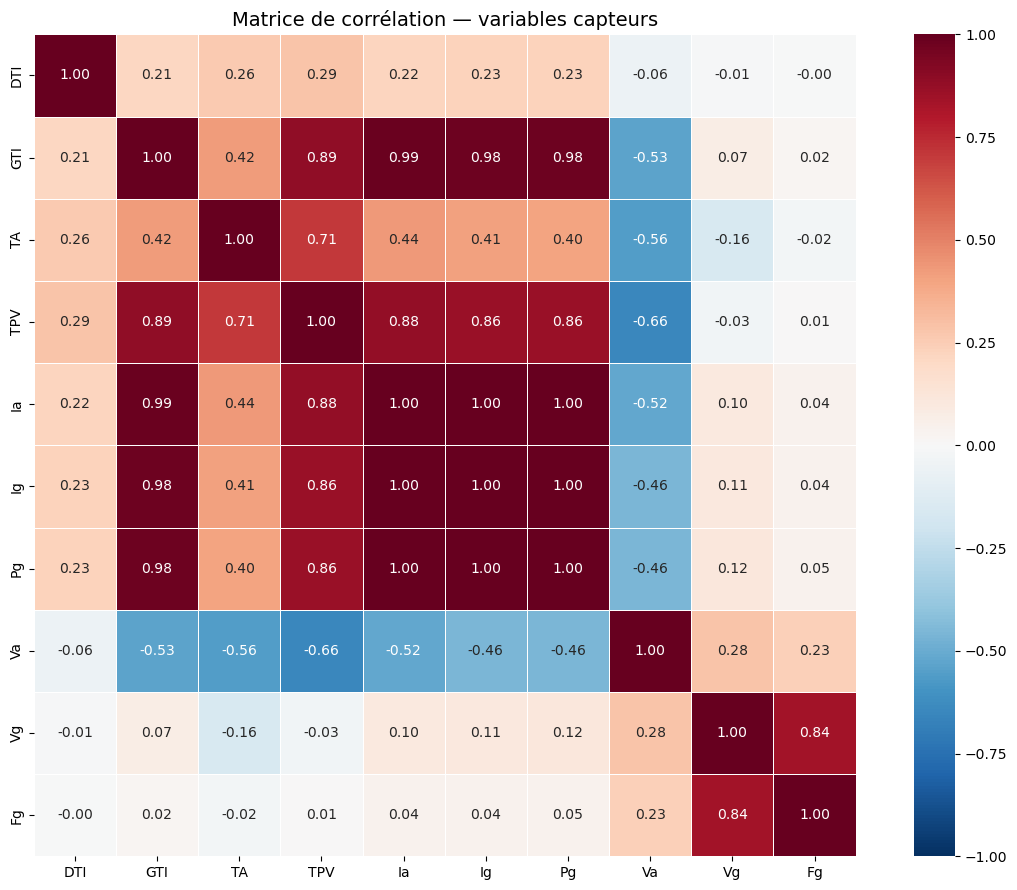

In [14]:

import seaborn as sns

features = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg"]

corr = df[features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Matrice de corrélation — variables capteurs", fontsize=14)
plt.tight_layout()
plt.show()

# Feature engineering

=== Nouvelles features ===
       ratio_pg_gti  delta_tpv_ta       pg_diff
count  52959.000000  52959.000000  52958.000000
mean       1.335552     12.589628     83.044088
std        0.176298      8.800248    129.196171
min        0.000000     -9.366367      0.000000
25%        1.259834      4.571550     12.800000
50%        1.324371     12.091567     29.991667
75%        1.412239     20.369017     89.612500
max        3.368972     34.607167   1299.025000


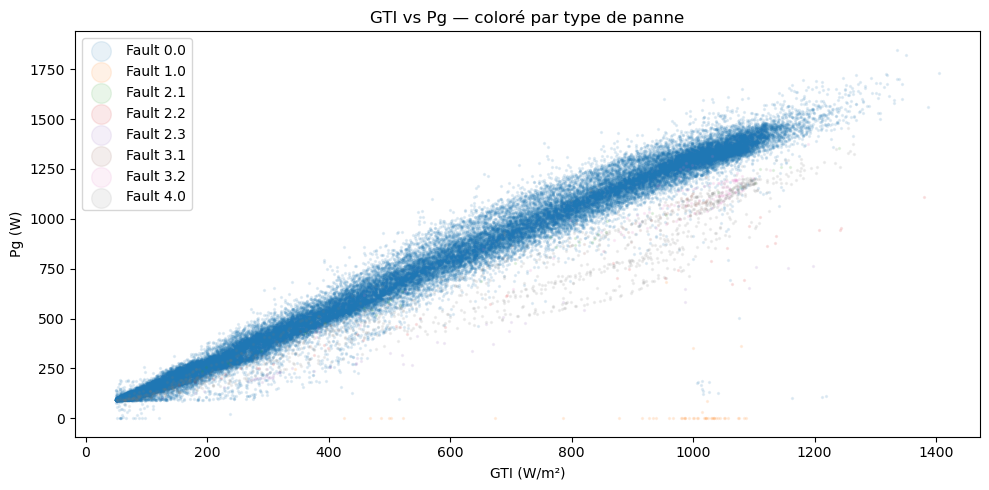

In [15]:

# Ratio rendement : production / irradiation
# Quand ce ratio chute, c'est une anomalie
df["ratio_pg_gti"] = df["Pg"] / df["GTI"].replace(0, np.nan)

# Échauffement anormal : température panneau - température ambiante
df["delta_tpv_ta"] = df["TPV"] - df["TA"]

# Variation brutale de puissance (dérivée)
df["pg_diff"] = df["Pg"].diff().abs()

# Vérification
print("=== Nouvelles features ===")
print(df[["ratio_pg_gti", "delta_tpv_ta", "pg_diff"]].describe())

# Visualiser le ratio par type de Fault
fig, ax = plt.subplots(figsize=(10, 5))
for fault_val in sorted(df["Fault"].unique()):
    subset = df[df["Fault"] == fault_val]
    ax.scatter(subset["GTI"], subset["Pg"], alpha=0.1, s=2, label=f"Fault {fault_val}")
ax.set_xlabel("GTI (W/m²)")
ax.set_ylabel("Pg (W)")
ax.set_title("GTI vs Pg — coloré par type de panne")
ax.legend(markerscale=10)
plt.tight_layout()
plt.show()

#  Zoom sur les anomalies

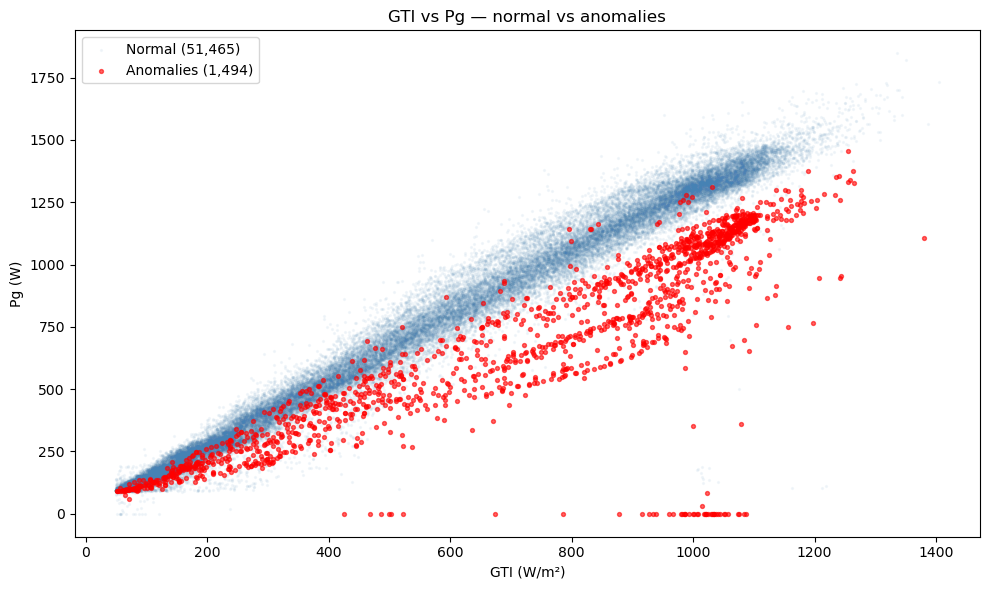

In [16]:

normal = df[df["Fault"] == 0]
anomalies = df[df["Fault"] != 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(normal["GTI"], normal["Pg"], alpha=0.05, s=2, c="steelblue", label=f"Normal ({len(normal):,})")
ax.scatter(anomalies["GTI"], anomalies["Pg"], alpha=0.6, s=8, c="red", label=f"Anomalies ({len(anomalies):,})")
ax.set_xlabel("GTI (W/m²)")
ax.set_ylabel("Pg (W)")
ax.set_title("GTI vs Pg — normal vs anomalies")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# Sauvegarder le dataset nettoyé avec features
df.to_csv("C:\\Users\\PC\\Documents\\pfa-photovoltaique\\pfa-photovoltaique\\data\\cleaned_with_features.csv")
print(f"Sauvegardé : {len(df):,} lignes x {len(df.columns)} colonnes")
print(f"Colonnes : {df.columns.tolist()}")

Sauvegardé : 52,959 lignes x 15 colonnes
Colonnes : ['DTI', 'GTI', 'TA', 'TPV', 'Ia', 'Ig', 'Eg', 'Fg', 'Pg', 'Va', 'Vg', 'Fault', 'ratio_pg_gti', 'delta_tpv_ta', 'pg_diff']


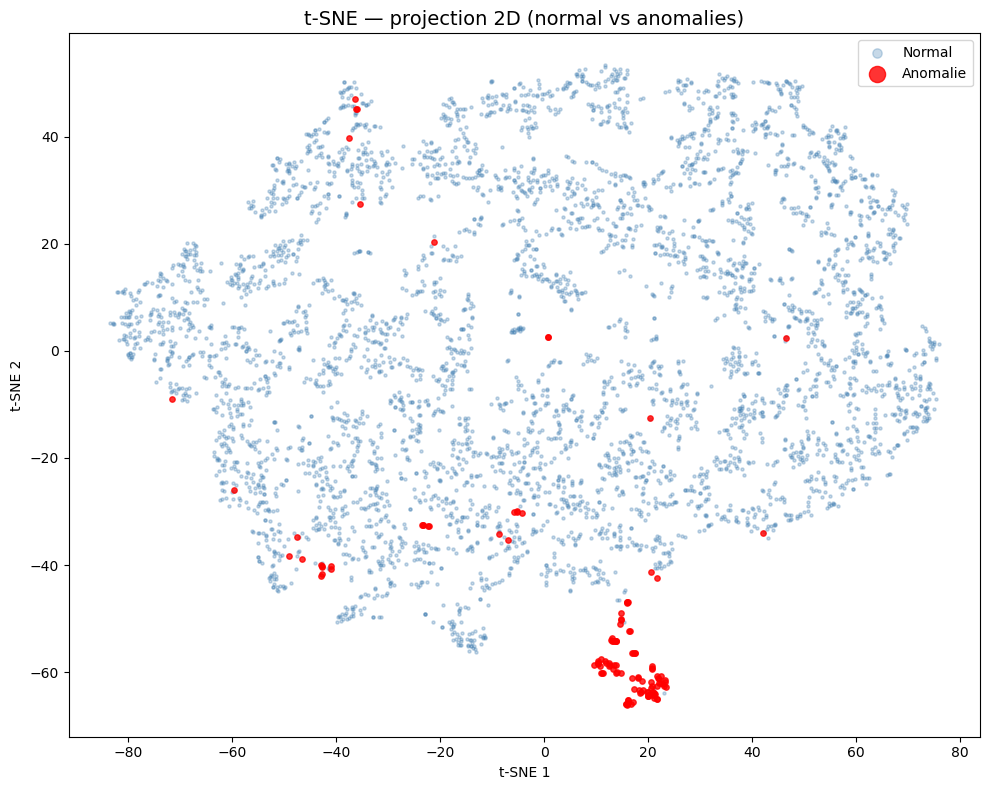

In [20]:
# %% t-SNE — projection 2D (prend 1-2 minutes)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

features_tsne = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "ratio_pg_gti", "delta_tpv_ta"]

# Échantillonner pour que t-SNE tourne en temps raisonnable
sample = df.sample(n=5000, random_state=42)
X_sample = sample[features_tsne].dropna()
sample = sample.loc[X_sample.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
normal_mask = sample["Fault"] == 0
ax.scatter(X_2d[normal_mask, 0], X_2d[normal_mask, 1], alpha=0.3, s=5, c="steelblue", label="Normal")
ax.scatter(X_2d[~normal_mask, 0], X_2d[~normal_mask, 1], alpha=0.8, s=15, c="red", label="Anomalie")
ax.set_title("t-SNE — projection 2D (normal vs anomalies)", fontsize=14)
ax.legend(markerscale=3)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

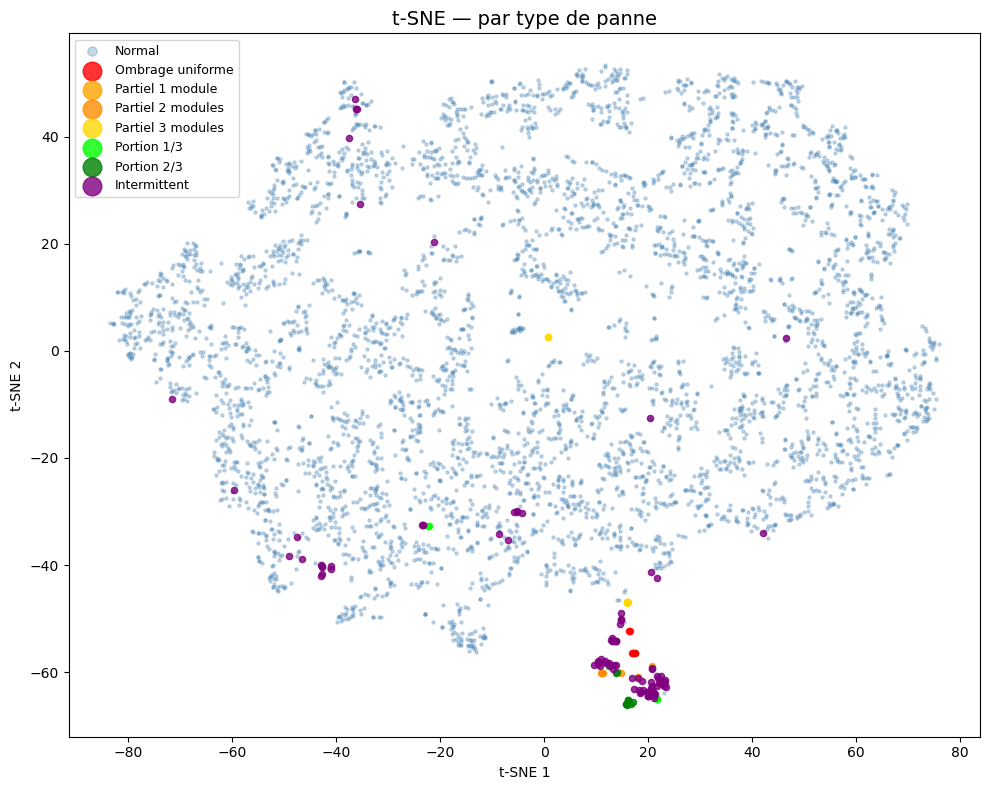

In [21]:
# %% t-SNE coloré par TYPE de panne
fig, ax = plt.subplots(figsize=(10, 8))

colors = {0.0: "steelblue", 1.0: "red", 2.1: "orange", 2.2: "darkorange",
          2.3: "gold", 3.1: "lime", 3.2: "green", 4.0: "purple"}
labels = {0.0: "Normal", 1.0: "Ombrage uniforme", 2.1: "Partiel 1 module",
          2.2: "Partiel 2 modules", 2.3: "Partiel 3 modules",
          3.1: "Portion 1/3", 3.2: "Portion 2/3", 4.0: "Intermittent"}

for fault_val in sorted(sample["Fault"].unique()):
    mask = sample["Fault"] == fault_val
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
              alpha=0.3 if fault_val == 0 else 0.8,
              s=5 if fault_val == 0 else 20,
              c=colors.get(fault_val, "gray"),
              label=labels.get(fault_val, f"Fault {fault_val}"))

ax.set_title("t-SNE — par type de panne", fontsize=14)
ax.legend(markerscale=3, fontsize=9)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

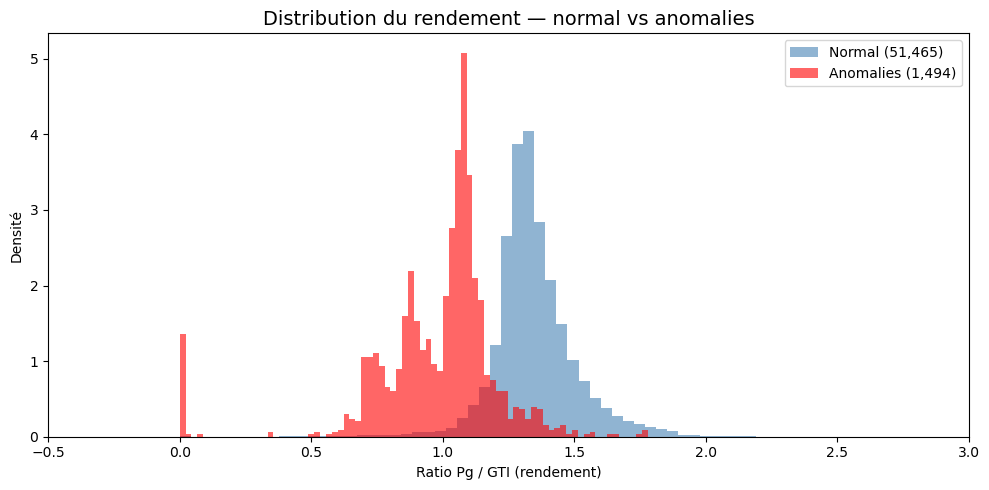

In [22]:
# %% Distribution du ratio Pg/GTI — normal vs anomalies
fig, ax = plt.subplots(figsize=(10, 5))
normal_ratio = df[df["Fault"] == 0]["ratio_pg_gti"].dropna()
anomaly_ratio = df[df["Fault"] != 0]["ratio_pg_gti"].dropna()

ax.hist(normal_ratio, bins=80, alpha=0.6, color="steelblue", label=f"Normal ({len(normal_ratio):,})", density=True)
ax.hist(anomaly_ratio, bins=80, alpha=0.6, color="red", label=f"Anomalies ({len(anomaly_ratio):,})", density=True)
ax.set_xlabel("Ratio Pg / GTI (rendement)")
ax.set_ylabel("Densité")
ax.set_title("Distribution du rendement — normal vs anomalies", fontsize=14)
ax.legend()
ax.set_xlim(-0.5, 3)
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_30992\489683664.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=[f"F{f}" for f in fault_types], patch_artist=True)


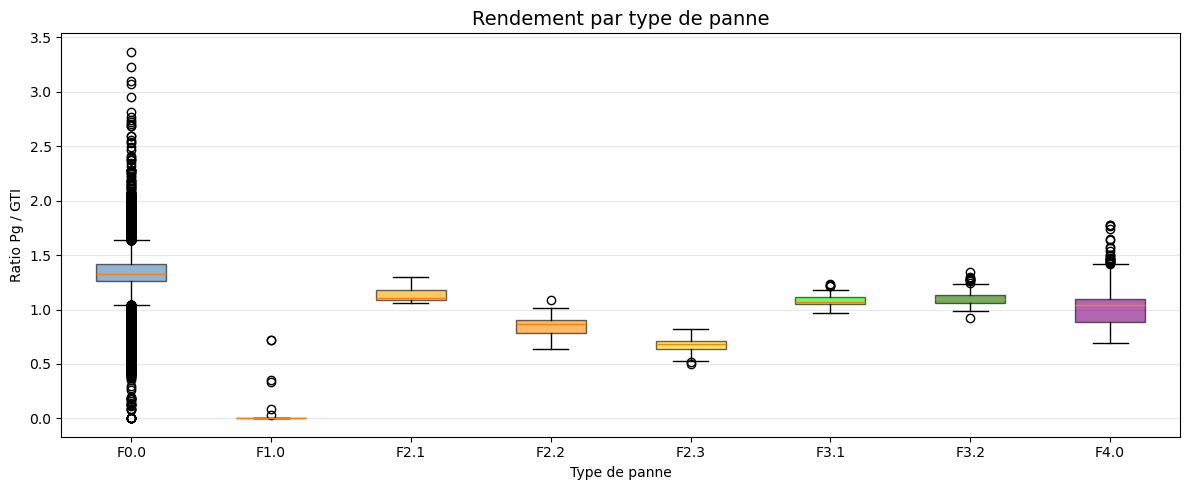

In [23]:
# %% Boxplot du ratio par type de Fault
fig, ax = plt.subplots(figsize=(12, 5))
fault_types = sorted(df["Fault"].unique())
data_box = [df[df["Fault"] == f]["ratio_pg_gti"].dropna().values for f in fault_types]
bp = ax.boxplot(data_box, labels=[f"F{f}" for f in fault_types], patch_artist=True)

colors_box = ["steelblue", "red", "orange", "darkorange", "gold", "lime", "green", "purple"]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_xlabel("Type de panne")
ax.set_ylabel("Ratio Pg / GTI")
ax.set_title("Rendement par type de panne", fontsize=14)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

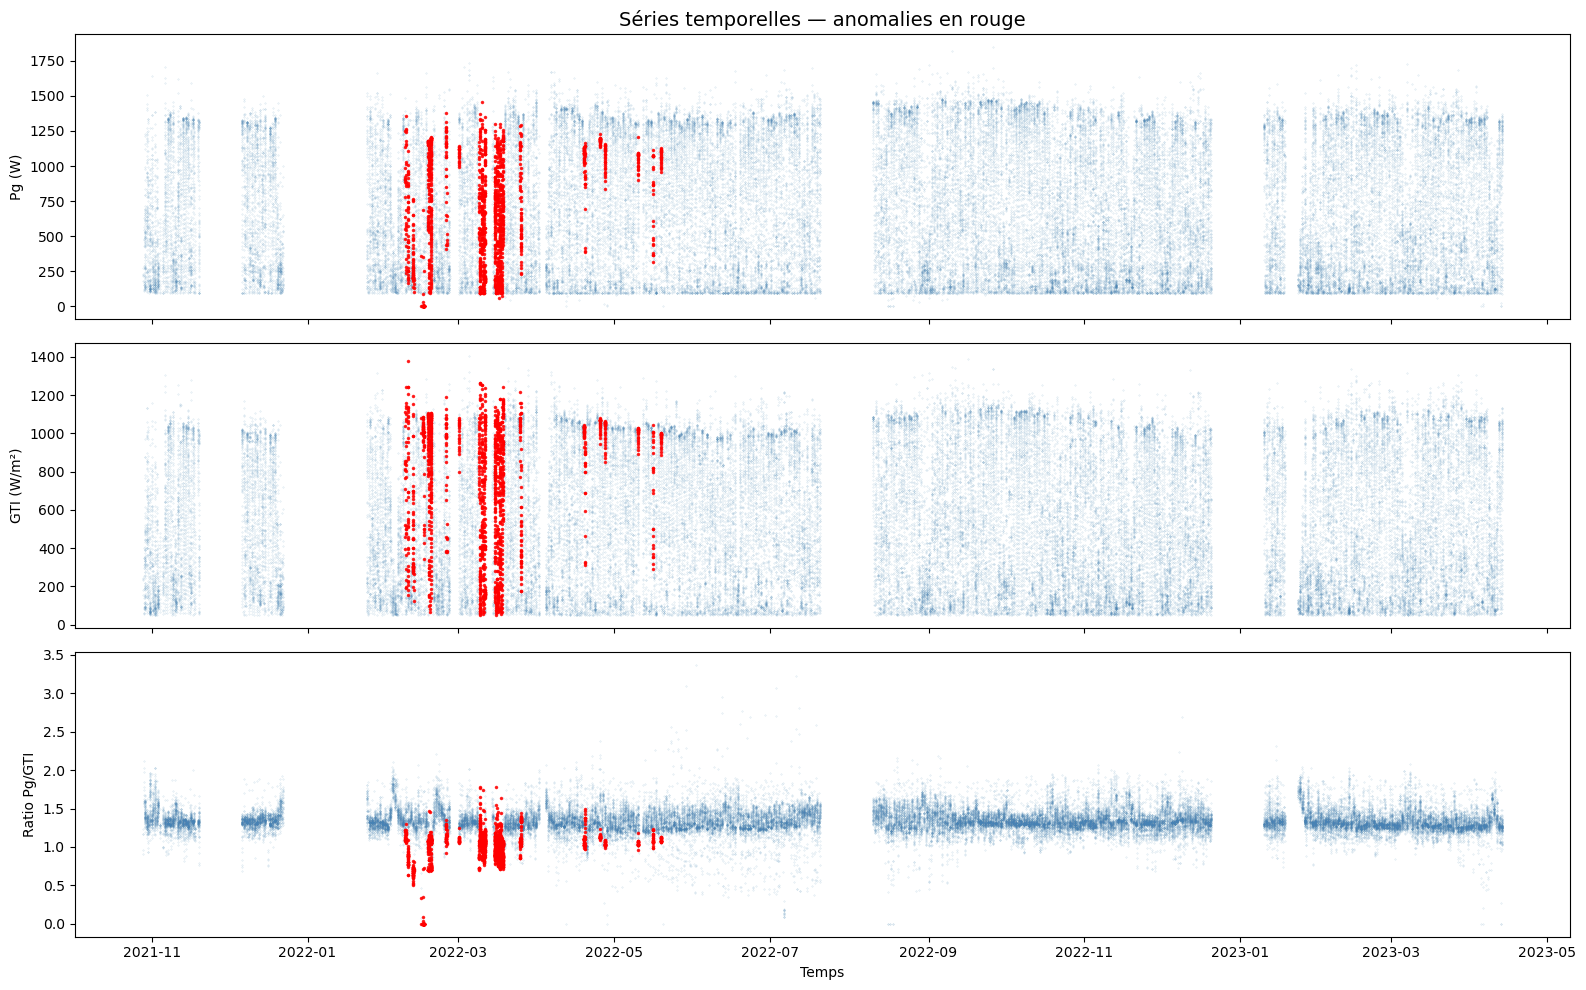

In [24]:
# %% Séries temporelles — Pg avec anomalies en rouge
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

normal = df[df["Fault"] == 0]
anomalies = df[df["Fault"] != 0]

# Pg
axes[0].plot(normal.index, normal["Pg"], ".", markersize=0.5, alpha=0.3, color="steelblue")
axes[0].plot(anomalies.index, anomalies["Pg"], ".", markersize=3, alpha=0.8, color="red")
axes[0].set_ylabel("Pg (W)")
axes[0].set_title("Séries temporelles — anomalies en rouge", fontsize=14)

# GTI
axes[1].plot(normal.index, normal["GTI"], ".", markersize=0.5, alpha=0.3, color="steelblue")
axes[1].plot(anomalies.index, anomalies["GTI"], ".", markersize=3, alpha=0.8, color="red")
axes[1].set_ylabel("GTI (W/m²)")

# Ratio
axes[2].plot(normal.index, normal["ratio_pg_gti"], ".", markersize=0.5, alpha=0.3, color="steelblue")
axes[2].plot(anomalies.index, anomalies["ratio_pg_gti"], ".", markersize=3, alpha=0.8, color="red")
axes[2].set_ylabel("Ratio Pg/GTI")
axes[2].set_xlabel("Temps")

plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_30992\3732802710.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["hour"] = anomalies.index.hour
C:\Users\PC\AppData\Local\Temp\ipykernel_30992\3732802710.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  anomalies["month"] = anomalies.index.to_period("M").astype(str)
C:\Users\PC\AppData\Local\Temp\ipykernel_30992\3732802710.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["month"] = anomal

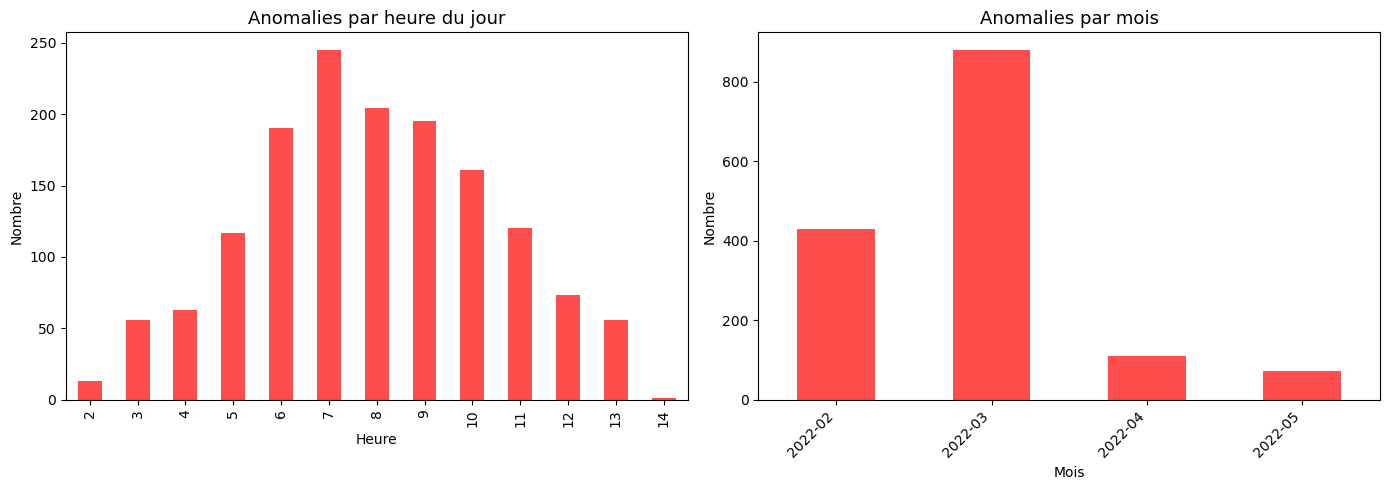

In [25]:
# %% Répartition temporelle des anomalies (quand arrivent-elles ?)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par heure de la journée
anomalies["hour"] = anomalies.index.hour
anomalies["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="red", alpha=0.7)
axes[0].set_title("Anomalies par heure du jour", fontsize=13)
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Nombre")

# Par mois
anomalies["month"] = anomalies.index.to_period("M").astype(str)
anomalies["month"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="red", alpha=0.7)
axes[1].set_title("Anomalies par mois", fontsize=13)
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Nombre")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

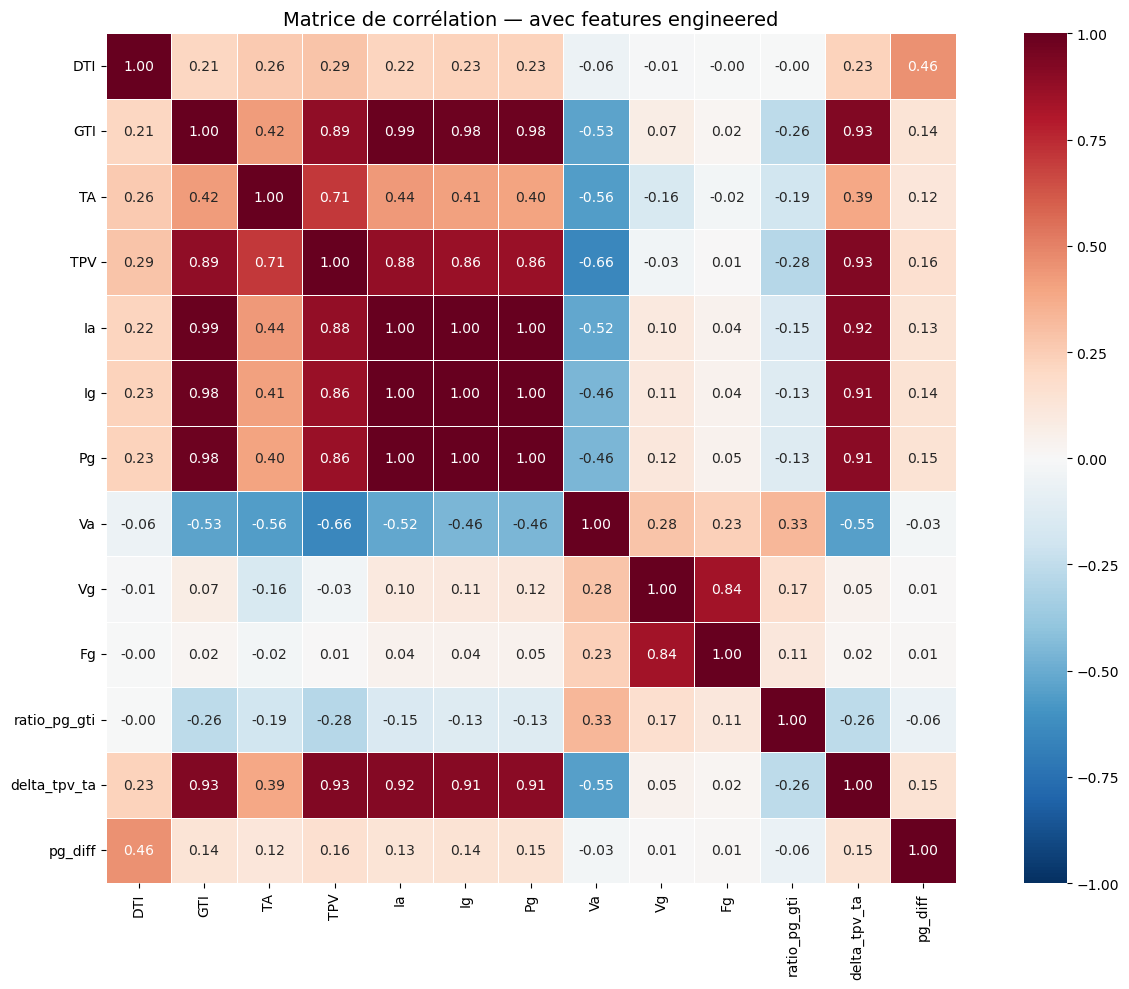

In [26]:
# %% Heatmap corrélation AVEC les nouvelles features
features_all = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg",
                "ratio_pg_gti", "delta_tpv_ta", "pg_diff"]

corr2 = df[features_all].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Matrice de corrélation — avec features engineered", fontsize=14)
plt.tight_layout()
plt.show()